In [1]:
import os
if not os.path.exists('plot_structure.py'):
    os.symlink('../../scripts/plot_structure.py', 'plot_structure.py')
import plot_structure
import pandas as pd
import pickle
import json
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200

In [2]:
# Load data
ptm_contact_dic = pickle.load(open("./data/cRDH.PTM.intra_interaction.summary.pkl", "rb"))
seq_feature_dic = json.load(open("./data/cRDH.secondary_structure_anno.json", "r"))
histMTR_df = pd.read_csv('./data/cRDH.HistMTR.obs_RGC.pred_MuRaL.tsv', sep='\t')

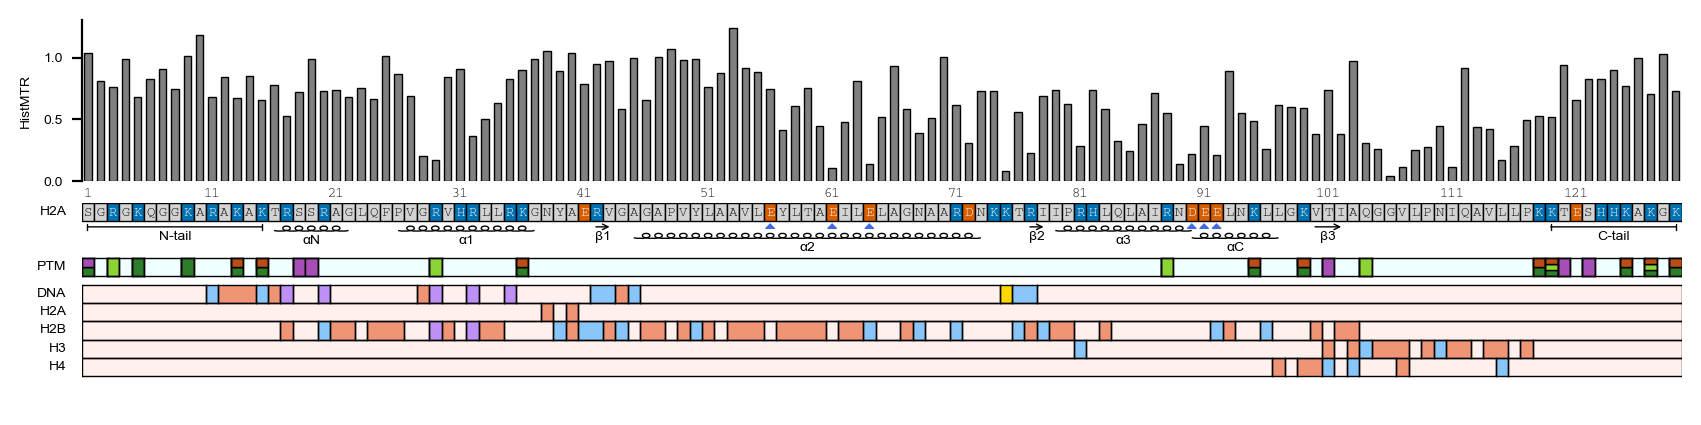

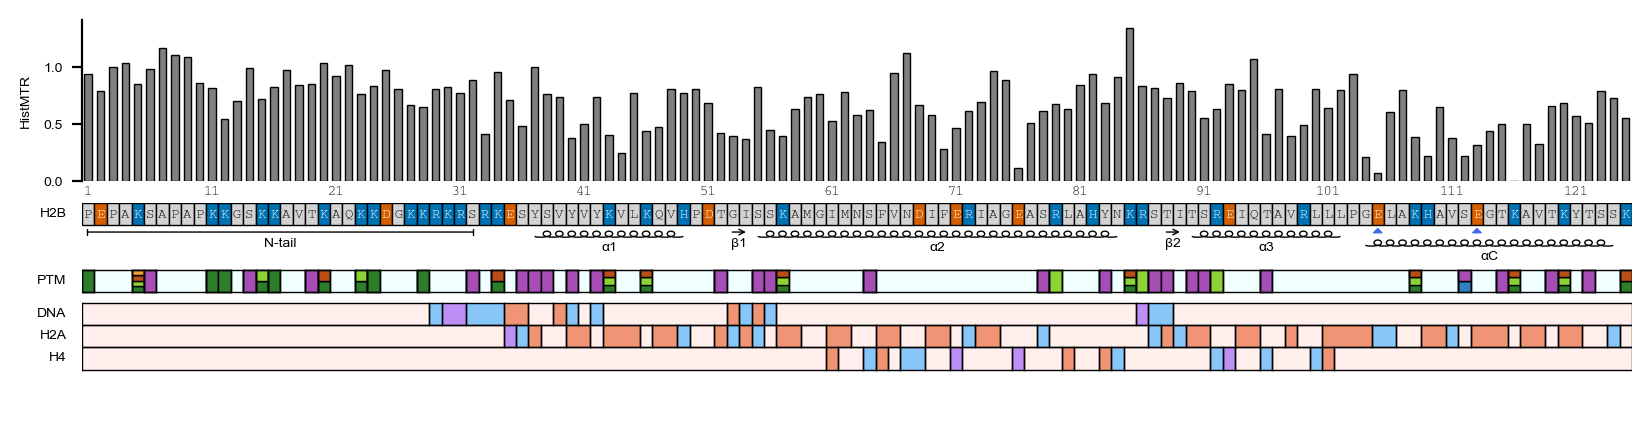

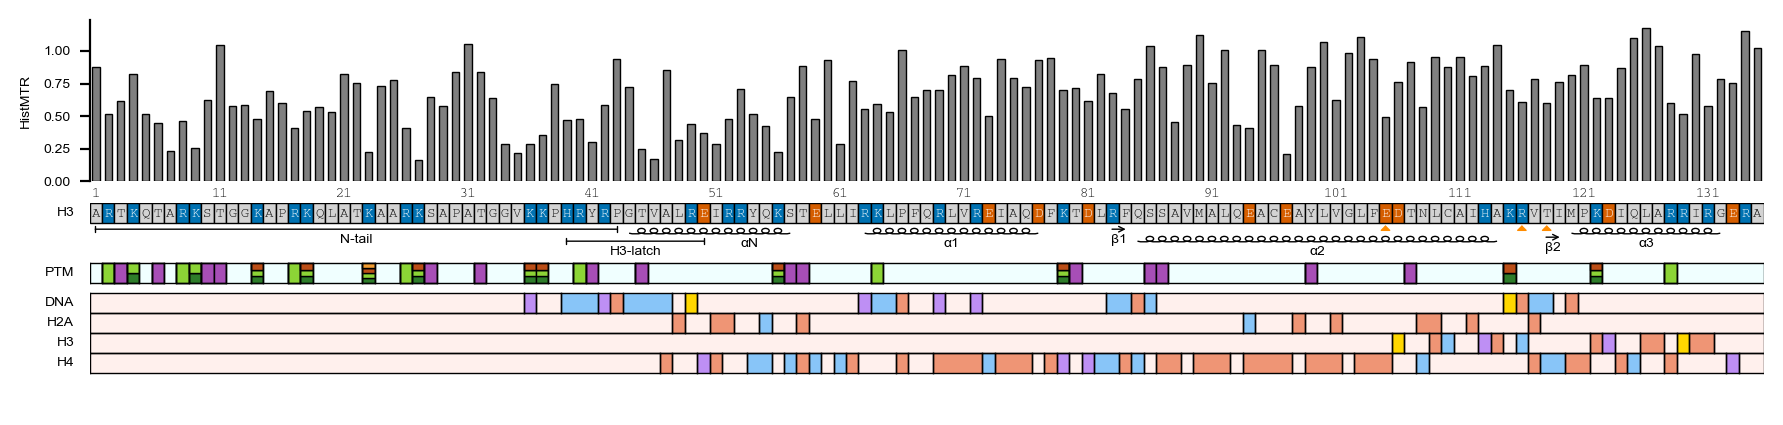

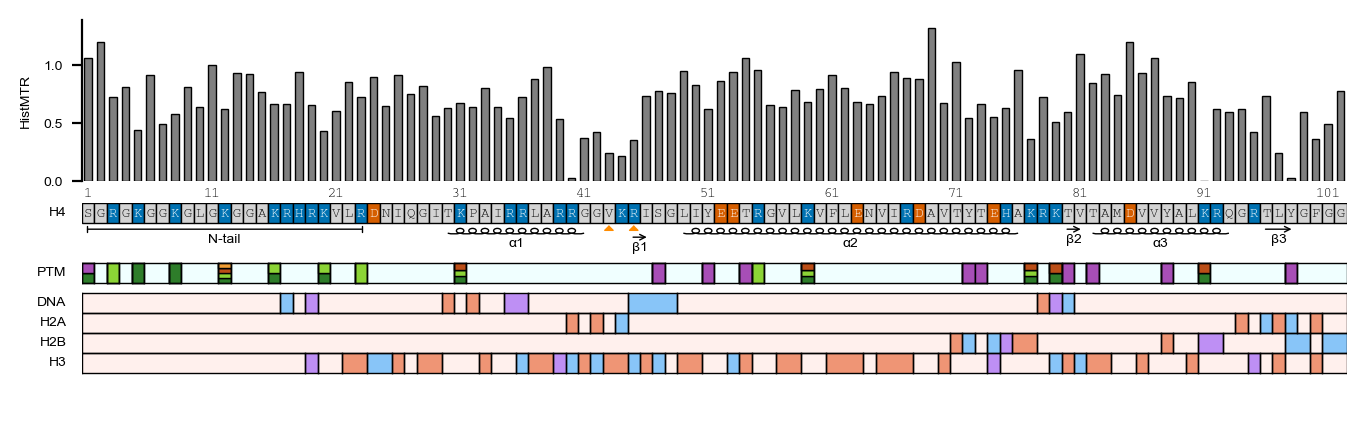

In [3]:
# Plot HistMTR with sequence features and PTM contacts
for family, df in histMTR_df.groupby('family'):

    fig, ax_bar, ax_seq = plot_structure.plot_peptide_sequence(  
        seq=df['amino acid'].values, # Amino acid sequence
        annotations=seq_feature_dic[family], # Sequence feature annotations
        per_amino_acid_width=0.08, # Width per amino acid
        figheight=2.5, # Figure height
        global_fontsize=5, # Font size
        values=df['HistMTR'].values, # HistMTR values
        hspace=0.12, # Height space between plots
        height_ratios=[4, 5], # Height ratios for bar and sequence plots
        seq_label=family, # Sequence label
        bar_label='HistMTR', # Bar plot label
        cut_start=True, # Cut start codon
        add_seqs=ptm_contact_dic[family], # Additional sequences (PTM & contacts)
        seq_offset=-3, # Offset for additional sequences
        gap_lst=[1.5], # Gap between sequences
        acidic_color='#d55e00', # Color for acidic residues
        basic_color='#0072b2', # Color for basic residues
        bar_width_ratio=0.6, # Bar width ratio
        )